# “Analisis Faktor-Faktor yang Memengaruhi Status Kemiskinan Provinsi di Indonesia Tahun 2024 Menggunakan Model Regresi Probit”
## Nama : Evinda Eka Ayudia Lestari
## NRP : 3323600039
## Kelas : 3 D4 SDT B

## Buat variabel dependen biner Y

In [21]:
# 1 = provinsi dengan tingkat kemiskinan di atas rata-rata nasional (8,57%)
# 0 = provinsi dengan tingkat kemiskinan di bawah atau sama dengan rata-rata nasional

import pandas as pd

data = pd.read_excel("Tingkat Kemiskinan 2024.xlsx")
print("Dataset Asli")
print(data.head())

# Gunakan angka resmi BPS untuk rata-rata nasional
cutoff_kemiskinan = 8.57

# Tambahkan kolom status kemiskinan (Y)
data["STATUS_KEMISKINAN"] = (data["KEMISKINAN"] > cutoff_kemiskinan).astype(int)

# Hapus kolom kemiskinan asli (tidak dipakai di model)
data_final = data.drop(columns=["KEMISKINAN"])
data_final.to_csv("Data_Kemiskinan_2024.csv", index=False)

print("\nData final berhasil disimpan")

Dataset Asli
         PROVINSI    IPM   TPT   RLS    PDRB  PENGKAP    TPAK  KEMISKINAN
0            ACEH  74.03  5.75  9.64   43782    10811  65.150       12.64
1  SUMATERA UTARA  74.02  5.60  9.93   73575    11460  71.395        7.19
2  SUMATERA BARAT  74.49  5.75  9.44   57047    11718  70.250        5.42
3            RIAU  74.79  3.70  9.43  165350    11857  65.925        6.36
4           JAMBI  73.43  4.48  8.90   86722    11621  68.605        7.26

Data final berhasil disimpan


## Import Library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

## 1. Baca Dataset

In [23]:
df = pd.read_csv("Data_Kemiskinan_2024.csv")
print("Jumlah data & kolom:", df.shape)
print("Nama kolom:", list(df.columns))
df

Jumlah data & kolom: (38, 8)
Nama kolom: ['PROVINSI', 'IPM', 'TPT', 'RLS', 'PDRB', 'PENGKAP', 'TPAK', 'STATUS_KEMISKINAN']


,PROVINSI,IPM,TPT,RLS,PDRB,PENGKAP,TPAK,STATUS_KEMISKINAN
0,ACEH,74.03,5.75,9.64,43782,10811,65.150,1
1,SUMATERA UTARA,74.02,5.60,9.93,73575,11460,71.395,0
2,SUMATERA BARAT,74.49,5.75,9.44,57047,11718,70.250,0
3,RIAU,74.79,3.70,9.43,165350,11857,65.925,0
4,JAMBI,73.43,4.48,8.90,86722,11621,68.605,0
5,SUMATERA SELATAN,72.30,3.86,8.57,75132,12015,70.570,1
6,BENGKULU,73.39,3.11,9.04,49233,11733,71.420,1
7,LAMPUNG,71.81,4.19,8.36,51370,11258,70.095,1
8,KEP. BANGKA BELITUNG,73.33,4.63,8.33,70194,13667,68.385,0
9,KEP. RIAU,77.97,6.39,10.50,161424,15573,68.940,0


## 2. Cek Informasi Awal

In [24]:
print("\nInfo Data:")
df.info()


Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PROVINSI           38 non-null     object 
 1   IPM                38 non-null     float64
 2   TPT                38 non-null     float64
 3   RLS                38 non-null     float64
 4   PDRB               38 non-null     int64  
 5   PENGKAP            38 non-null     int64  
 6   TPAK               38 non-null     float64
 7   STATUS_KEMISKINAN  38 non-null     int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 2.5+ KB


In [25]:
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,IPM,TPT,RLS,PDRB,PENGKAP,TPAK,STATUS_KEMISKINAN
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,72.388421,4.379737,8.841316,84343.736842,11538.289474,70.449605,0.526316
std,5.150227,1.414222,1.227811,62197.160318,2470.381521,4.380399,0.506009
min,53.420000,1.320000,4.210000,18105.000000,5707.000000,65.095000,0.000000
25%,71.080000,3.217500,8.300000,51395.750000,10214.750000,67.632500,0.000000
50%,73.180000,4.190000,8.885000,68596.000000,11572.500000,70.047500,1.000000
75%,74.345000,5.712500,9.515000,80586.750000,12296.250000,71.413750,1.000000
max,83.080000,6.750000,11.490000,344350.000000,19953.000000,88.040000,1.000000


In [26]:
print("\nJumlah Missing Value:")
df.isnull().sum()


Jumlah Missing Value:


PROVINSI             0
IPM                  0
TPT                  0
RLS                  0
PDRB                 0
PENGKAP              0
TPAK                 0
STATUS_KEMISKINAN    0
dtype: int64

## 3. Eksplorasi Awal Variabel Dependen

STATUS_KEMISKINAN
1    20
0    18
Name: count, dtype: int64


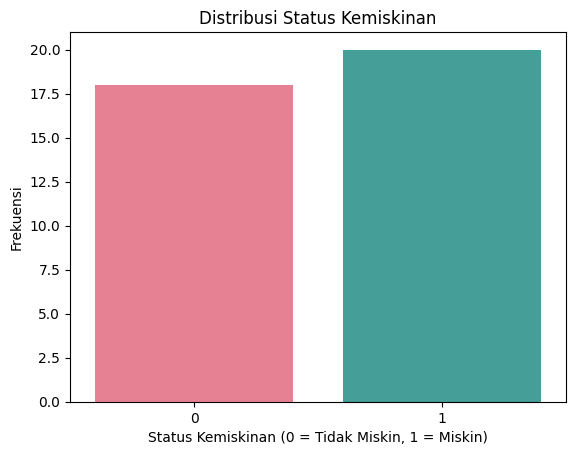

In [27]:
print(df['STATUS_KEMISKINAN'].value_counts())

sns.countplot(x='STATUS_KEMISKINAN', hue='STATUS_KEMISKINAN', data=df, palette='husl', legend=False)
plt.title('Distribusi Status Kemiskinan')
plt.xlabel('Status Kemiskinan (0 = Tidak Miskin, 1 = Miskin)')
plt.ylabel('Frekuensi')
plt.show()

In [28]:
# Hitung proporsi kategori
count_non_poor = len(df[df['STATUS_KEMISKINAN'] == 0])
count_poor = len(df[df['STATUS_KEMISKINAN'] == 1])
pct_non_poor = count_non_poor / (count_non_poor + count_poor)
pct_poor = count_poor / (count_non_poor + count_poor)

print(f"Persentase Tidak Miskin : {pct_non_poor * 100:.2f}%")
print(f"Persentase Miskin       : {pct_poor * 100:.2f}%")

print("\nRata-rata variabel independen berdasarkan status kemiskinan:")
print(df.groupby('STATUS_KEMISKINAN').mean(numeric_only=True))

Persentase Tidak Miskin : 47.37%
Persentase Miskin       : 52.63%

Rata-rata variabel independen berdasarkan status kemiskinan:
                         IPM       TPT       RLS           PDRB       PENGKAP  \
STATUS_KEMISKINAN                                                               
0                  74.757222  4.897778  9.350556  109759.222222  12643.833333   
1                  70.256500  3.913500  8.383000   61469.800000  10543.300000   

                        TPAK  
STATUS_KEMISKINAN             
0                  68.618889  
1                  72.097250  


## 4. Visualisasi Distribusi Variabel Numerik

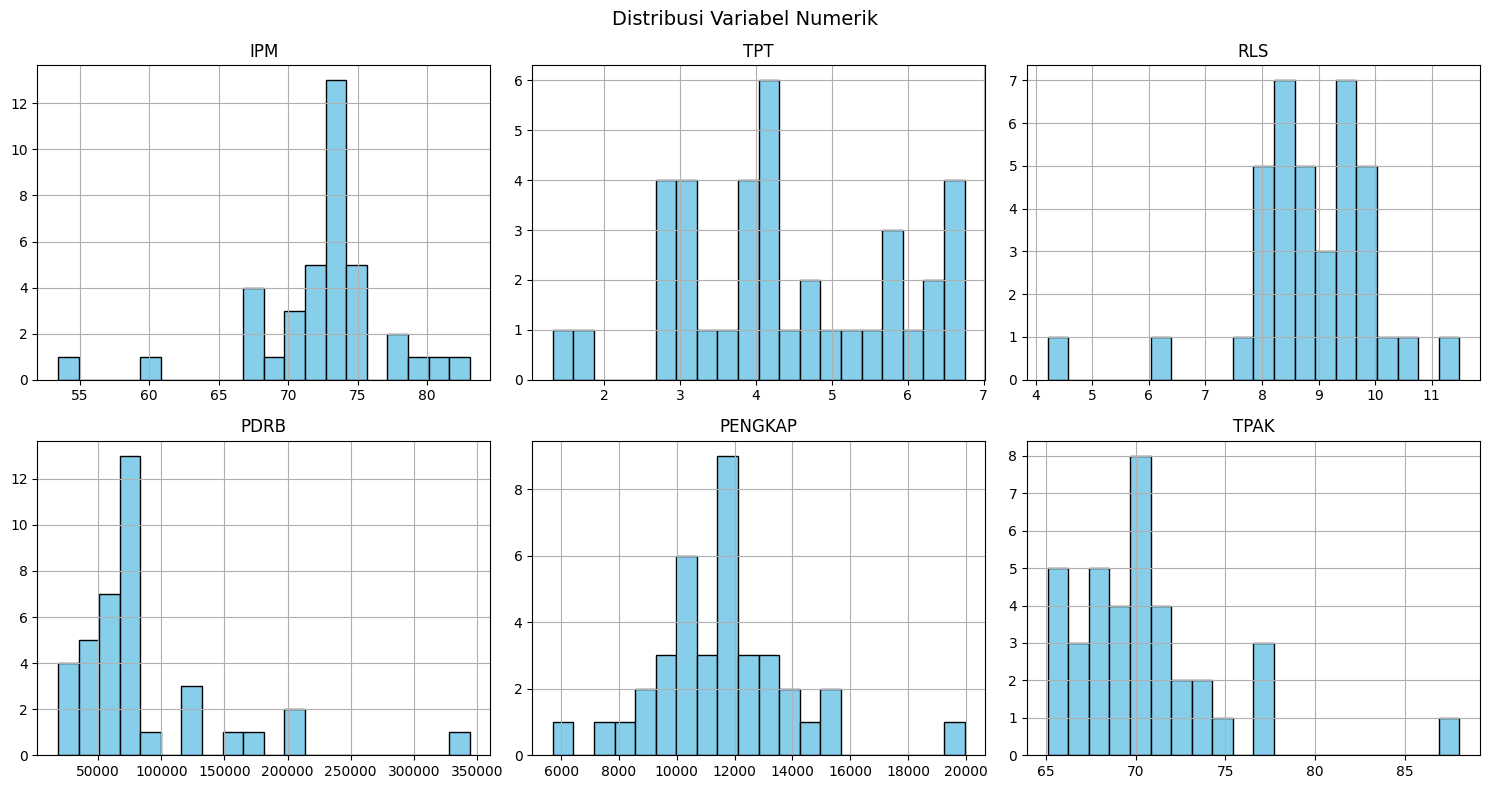

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('STATUS_KEMISKINAN')

df[numeric_cols].hist(figsize=(15, 8), layout=(2, 3), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribusi Variabel Numerik", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Tentukan Variabel Independen & Dependen

In [30]:
X = df[['IPM', 'TPT', 'RLS', 'PDRB', 'PENGKAP', 'TPAK']] # Independen
y = df['STATUS_KEMISKINAN'] # Dependen

## 6. Feature Selection dengan RFE (Recursive Feature Elimination)

In [31]:
logreg = LogisticRegression(max_iter=1000)
n_features_to_select = X.shape[1]

rfe = RFE(estimator=logreg, n_features_to_select=n_features_to_select)
rfe = rfe.fit(X, y)

print("Support (True = terpilih):", rfe.support_)
print("Ranking (1 = paling penting):", rfe.ranking_)

Support (True = terpilih): [ True  True  True  True  True  True]
Ranking (1 = paling penting): [1 1 1 1 1 1]


## 7. Standardisasi Variabel Independen

In [32]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)

## 8. Analisis Multikolinearitas (Korelasi & VIF)

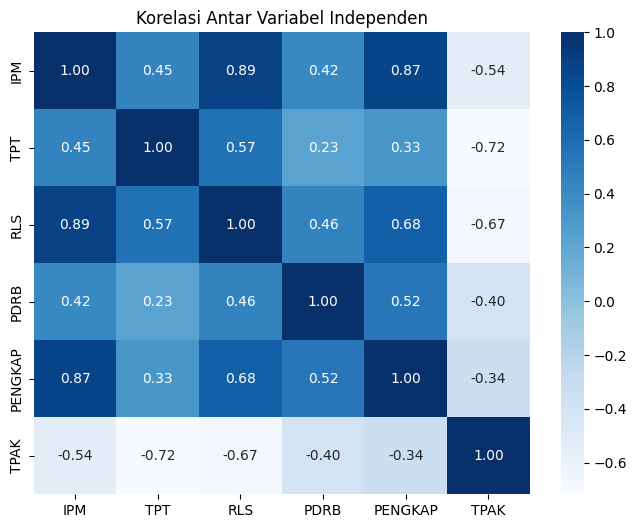

In [33]:
# Korelasi antar variabel
corr = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Antar Variabel Independen")
plt.show()

In [34]:
# Hitung Variance Inflation Factor (VIF)
def calculate_vif(df_features):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_features.columns
    vif_data["VIF"] = [variance_inflation_factor(df_features.values, i)
                       for i in range(df_features.shape[1])]
    return vif_data

vif_df = calculate_vif(X_std)
print(vif_df)

   Feature        VIF
0      IPM  14.505694
1      TPT   2.261259
2      RLS   7.845645
3     PDRB   1.838047
4  PENGKAP   6.741280
5     TPAK   3.045708


In [35]:
# Handling Multikolinearitas Otomatis (hapus VIF > 10)
threshold = 10
while True:
    vif_df = calculate_vif(X_std)
    max_vif = vif_df["VIF"].max()
    if max_vif > threshold:
        remove_col = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
        print(f"Menghapus '{remove_col}' karena VIF = {max_vif:.2f} > {threshold}")
        X_std = X_std.drop(columns=[remove_col])
    else:
        break

print("\nVariabel Akhir Setelah Menghapus Multikolinearitas Tinggi:")
print(X_std.columns.tolist())

Menghapus 'IPM' karena VIF = 14.51 > 10

Variabel Akhir Setelah Menghapus Multikolinearitas Tinggi:
['TPT', 'RLS', 'PDRB', 'PENGKAP', 'TPAK']


## 9. Estimasi Model Regresi Probit

In [36]:
print("\n=== Model Probit ===")
X_std = sm.add_constant(X_std)
model = sm.Probit(y, X_std)
result = model.fit()
print(result.summary())


=== Model Probit ===
Optimization terminated successfully.
         Current function value: 0.415684
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:      STATUS_KEMISKINAN   No. Observations:                   38
Model:                         Probit   Df Residuals:                       32
Method:                           MLE   Df Model:                            5
Date:                Wed, 01 Oct 2025   Pseudo R-squ.:                  0.3991
Time:                        21:48:05   Log-Likelihood:                -15.796
converged:                       True   LL-Null:                       -26.287
Covariance Type:            nonrobust   LLR p-value:                 0.0008165
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0481      0.301     -0.160      0.873      -0.639       0.543
TPT    

## 10. Analisis Efek Marginal (Marginal Effects)

In [37]:
print("\n=== Efek Marginal (Marginal Effects - Model Standar) ===")
mfx = result.get_margeff(at='mean', method='dydx')
print(mfx.summary())


=== Efek Marginal (Marginal Effects - Model Standar) ===
       Probit Marginal Effects       
Dep. Variable:      STATUS_KEMISKINAN
Method:                          dydx
At:                              mean
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
TPT           -0.0467      0.162     -0.288      0.773      -0.364       0.271
RLS           -0.0071      0.186     -0.038      0.969      -0.372       0.358
PDRB          -0.4175      0.248     -1.681      0.093      -0.904       0.069
PENGKAP       -0.4815      0.203     -2.368      0.018      -0.880      -0.083
TPAK           0.4022      0.251      1.600      0.110      -0.091       0.895


## 11. Evaluasi Model Probit dengan Probabilitas
Menghitung Peluang (Probabilitas) Setiap Provinsi Masuk Kategori Miskin untuk interpretasi tingkat kerentanan tiap provinsi terhadap kemiskinan berdasarkan kondisi tahun 2024.

In [38]:
# Prediksi probabilitas dan kelas berdasarkan model
y_pred_prob = result.predict(X_std)
y_pred_class = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y, y_pred_class)
acc = accuracy_score(y, y_pred_class)

print("\nConfusion Matrix:\n", cm)
print(f"Akurasi Model: {acc:.3f}")

df['Prob_Miskin'] = y_pred_prob.round(4)
df['Pred_Status'] = y_pred_class

print("\n=== Hasil Prediksi Probabilitas dan Klasifikasi ===")
display(df[['PROVINSI', 'Prob_Miskin', 'STATUS_KEMISKINAN', 'Pred_Status']]
        .sort_values(by='Prob_Miskin', ascending=False).head(10))


Confusion Matrix:
 [[12  6]
 [ 4 16]]
Akurasi Model: 0.737

=== Hasil Prediksi Probabilitas dan Klasifikasi ===


,PROVINSI,Prob_Miskin,STATUS_KEMISKINAN,Pred_Status
37,PAPUA PEGUNUNGAN,1.0000,1,1
18,NUSA TENGGARA TIMUR,1.0000,1,1
17,NUSA TENGGARA BARAT,0.9946,1,1
36,PAPUA TENGAH,0.9635,1,1
29,SULAWESI BARAT,0.9506,1,1
35,PAPUA SELATAN,0.9188,1,1
27,SULAWESI TENGGARA,0.9054,1,1
19,KALIMANTAN BARAT,0.8329,0,1
12,JAWA TENGAH,0.8299,1,1
31,MALUKU UTARA,0.8148,0,1


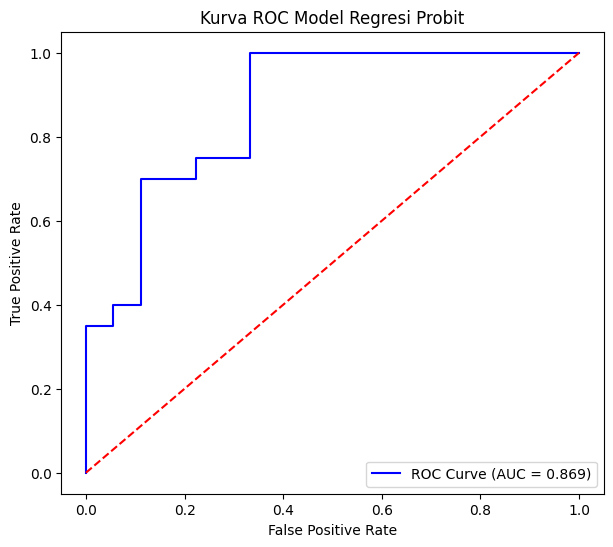

In [39]:
# Hitung nilai ROC & AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
auc_score = roc_auc_score(y, y_pred_prob)

# Plot kurva ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC Model Regresi Probit')
plt.legend(loc='lower right')
plt.show()